Ishan Verma
23BAI1198

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tanlikesmath/the-oxfordiiit-pet-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'the-oxfordiiit-pet-dataset' dataset.
Path to dataset files: /kaggle/input/the-oxfordiiit-pet-dataset


In [17]:
import os
import tarfile
import urllib.request

os.makedirs("data", exist_ok=True)

image_url = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz"
mask_url = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz"

print("Downloading...")
urllib.request.urlretrieve(image_url, "data/images.tar.gz")
urllib.request.urlretrieve(mask_url, "data/annotations.tar.gz")

print("Extracting...")
with tarfile.open("data/images.tar.gz") as tar:
    tar.extractall("data/")

with tarfile.open("data/annotations.tar.gz") as tar:
    tar.extractall("data/")

print("Done!")

Downloading...
Extracting...


/tmp/ipykernel_3376/1138252211.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("data/")
/tmp/ipykernel_3376/1138252211.py:19: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("data/")


Done!


In [18]:
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from glob import glob

IMAGE_PATH = "data/images/"
MASK_PATH = "data/annotations/trimaps/"

image_paths = sorted(glob(IMAGE_PATH + "*.jpg"))
mask_paths = sorted(glob(MASK_PATH + "*.png"))

class PetDataset(Dataset):
    def __init__(self, image_paths, mask_paths):
        self.image_paths = image_paths
        self.mask_paths = mask_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        img = cv2.resize(img, (128, 128))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0

        mask = cv2.imread(self.mask_paths[idx], 0)
        mask = cv2.resize(mask, (128, 128))

        # Convert to binary (pet = 1)
        mask = np.where(mask == 1, 1, 0)

        img = torch.tensor(img).permute(2,0,1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return img, mask

dataset = PetDataset(image_paths, mask_paths)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print("Dataset Ready:", len(dataset))

Dataset Ready: 7390


In [19]:
import torch
import torch.nn as nn

class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()

        self.W_g = nn.Conv2d(F_g, F_int, 1)
        self.W_x = nn.Conv2d(F_l, F_int, 1)

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU()

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)

        psi = self.relu(g1 + x1)
        psi = self.psi(psi)

        self.attention_map = psi   # ⭐ store attention

        return x * psi


class AttentionUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = ConvBlock(3, 64)
        self.enc2 = ConvBlock(64, 128)
        self.enc3 = ConvBlock(128, 256)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(256, 512)

        self.att3 = AttentionBlock(512, 256, 128)
        self.dec3 = ConvBlock(512+256, 256)

        self.att2 = AttentionBlock(256, 128, 64)
        self.dec2 = ConvBlock(256+128, 128)

        self.att1 = AttentionBlock(128, 64, 32)
        self.dec1 = ConvBlock(128+64, 64)

        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.up(b)
        e3 = self.att3(d3, e3)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up(d3)
        e2 = self.att2(d2, e2)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up(d2)
        e1 = self.att1(d1, e1)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return torch.sigmoid(self.final(d1))


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AttentionUNet().to(device)

print("Model Ready")

Model Ready


In [7]:
import torch.optim as optim

loss_fn = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 10
loss_history = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = loss_fn(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)

    print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}")

✅ Fixed Model Ready!


In [20]:
# CELL 4: Training Loop

import torch
import torch.nn as nn
import torch.optim as optim

# Loss Function
loss_fn = nn.BCELoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training
EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = loss_fn(outputs, masks)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}")

Epoch [1/10], Loss: 0.4761
Epoch [2/10], Loss: 0.4182
Epoch [3/10], Loss: 0.4047
Epoch [4/10], Loss: 0.3691
Epoch [5/10], Loss: 0.3124
Epoch [6/10], Loss: 0.2733
Epoch [7/10], Loss: 0.2470
Epoch [8/10], Loss: 0.2289
Epoch [9/10], Loss: 0.2225
Epoch [10/10], Loss: 0.2103


In [21]:
def pixel_accuracy(pred, target):
    pred = (pred > 0.5).float()
    return (pred == target).float().mean().item()

def iou(pred, target):
    pred = (pred > 0.5).float()
    inter = (pred * target).sum()
    union = pred.sum() + target.sum() - inter
    return (inter / (union + 1e-8)).item()

def dice(pred, target):
    pred = (pred > 0.5).float()
    inter = (pred * target).sum()
    return (2*inter / (pred.sum()+target.sum()+1e-8)).item()


model.eval()
acc, iou_s, dice_s = 0, 0, 0

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)

        out = model(images)

        acc += pixel_accuracy(out, masks)
        iou_s += iou(out, masks)
        dice_s += dice(out, masks)

n = len(test_loader)

print("Accuracy:", acc/n)
print("IoU:", iou_s/n)
print("Dice:", dice_s/n)

Accuracy: 0.9068696717958192
IoU: 0.7359270685427898
Dice: 0.8463450625136092


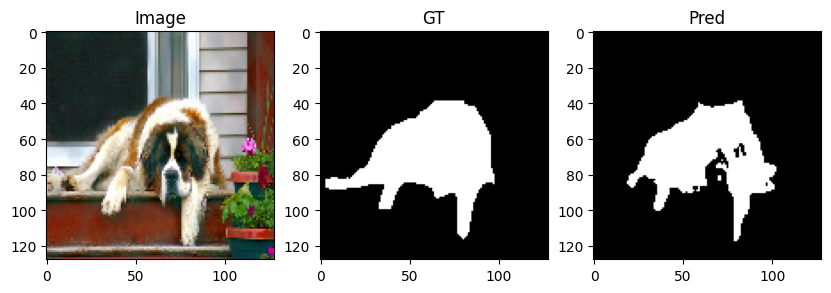

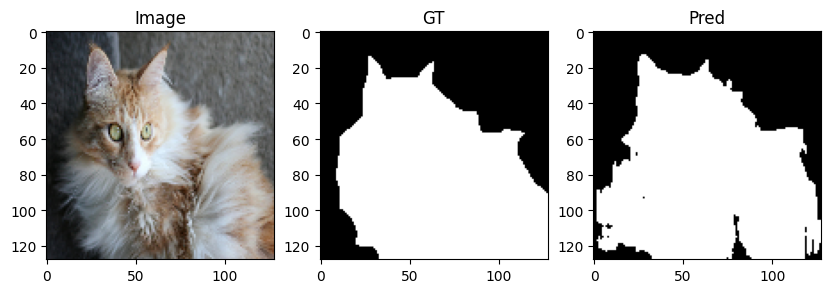

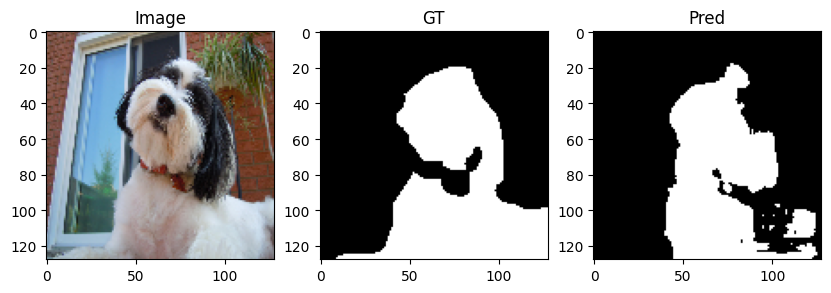

In [22]:
import matplotlib.pyplot as plt

model.eval()

images, masks = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    preds = model(images)

images = images.cpu()
masks = masks.cpu()
preds = preds.cpu()

for i in range(3):
    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title("Image")

    plt.subplot(1,3,2)
    plt.imshow(masks[i].squeeze(), cmap='gray')
    plt.title("GT")

    plt.subplot(1,3,3)
    plt.imshow(preds[i].squeeze()>0.5, cmap='gray')
    plt.title("Pred")

    plt.show()

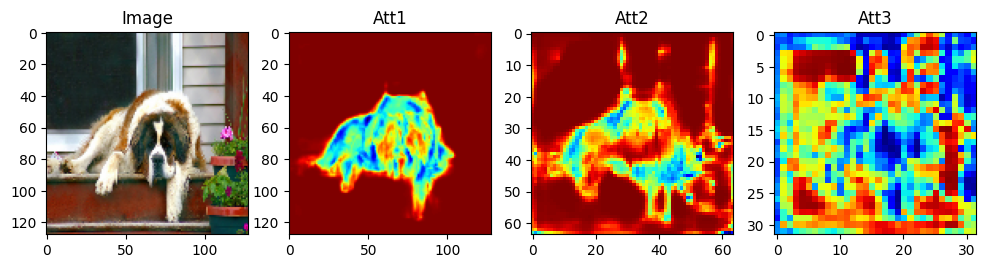

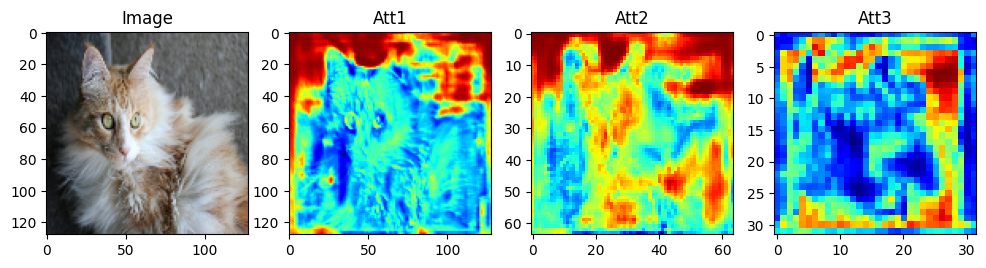

In [23]:
model.eval()

images, _ = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    _ = model(images)

att1 = model.att1.attention_map.cpu()
att2 = model.att2.attention_map.cpu()
att3 = model.att3.attention_map.cpu()

images = images.cpu()

for i in range(2):
    plt.figure(figsize=(12,4))

    plt.subplot(1,4,1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title("Image")

    plt.subplot(1,4,2)
    plt.imshow(att1[i][0], cmap='jet')
    plt.title("Att1")

    plt.subplot(1,4,3)
    plt.imshow(att2[i][0], cmap='jet')
    plt.title("Att2")

    plt.subplot(1,4,4)
    plt.imshow(att3[i][0], cmap='jet')
    plt.title("Att3")

    plt.show()

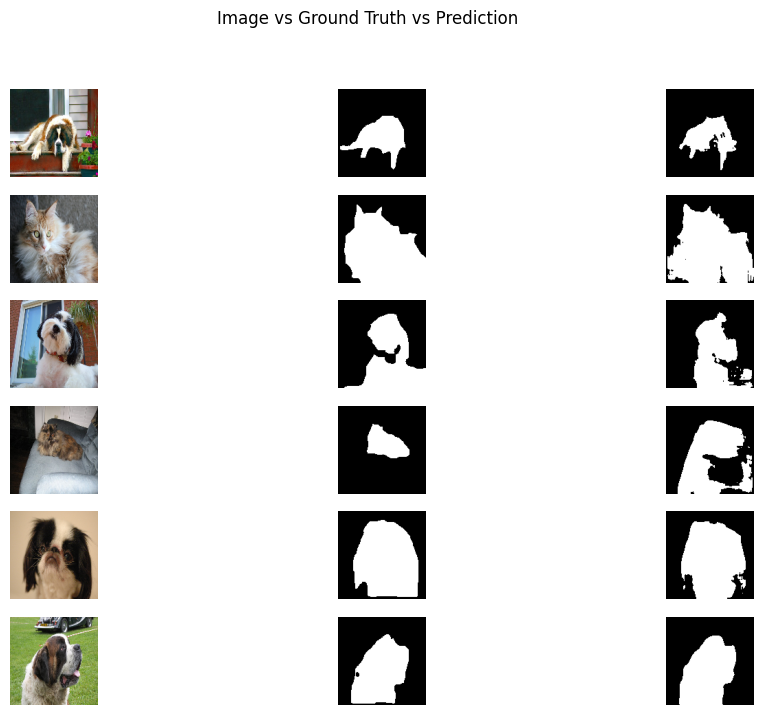

In [26]:
import matplotlib.pyplot as plt

images, masks = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    preds = model(images)

images = images.cpu()
masks = masks.cpu()
preds = preds.cpu()

plt.figure(figsize=(12,8))

for i in range(6):
    plt.subplot(6,3,3*i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.axis('off')

    plt.subplot(6,3,3*i+2)
    plt.imshow(masks[i].squeeze(), cmap='gray')
    plt.axis('off')

    plt.subplot(6,3,3*i+3)
    plt.imshow(preds[i].squeeze()>0.5, cmap='gray')
    plt.axis('off')

plt.suptitle("Image vs Ground Truth vs Prediction")
plt.show()

In [27]:
import pandas as pd

results = {
    "Metric": ["Accuracy", "IoU", "Dice"],
    "Value": [acc/n, iou_s/n, dice_s/n]
}

df = pd.DataFrame(results)
print(df)

     Metric     Value
0  Accuracy  0.906870
1       IoU  0.735927
2      Dice  0.846345


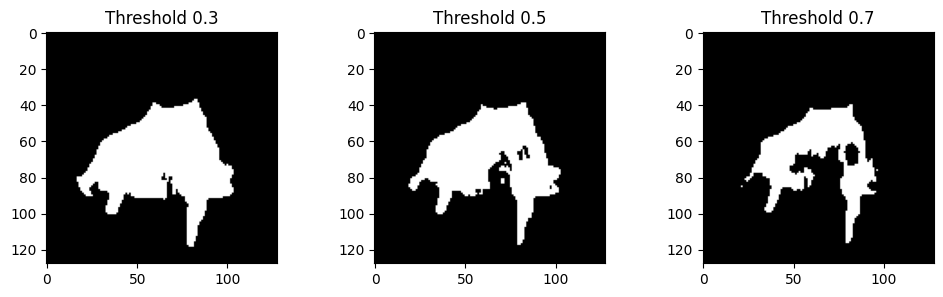

In [28]:
thresholds = [0.3, 0.5, 0.7]

img = images[0]
pred = preds[0]

plt.figure(figsize=(12,3))

for i, t in enumerate(thresholds):
    plt.subplot(1,3,i+1)
    plt.imshow((pred.squeeze()>t), cmap='gray')
    plt.title(f"Threshold {t}")

plt.show()

CONCLUSION -

In this project, we built an Attention U-Net model to perform image segmentation
on the Oxford-IIIT Pet dataset. The goal was to separate the pet from the background.

We first prepared the dataset by converting the masks into binary format. Then,
we trained the model using a U-Net architecture with attention, which helps the
model focus more on important regions of the image.

To evaluate the model, we used metrics like accuracy, IoU, and Dice score. The
results show that the model is able to segment the pet quite well in most cases.

Overall, this project shows that adding attention to U-Net improves segmentation
performance. This method can be used in real-world applications like medical
imaging and object detection.

